In [24]:
run -i run.py --scene sun_earth_l2 --level 1 --mission_name "Halo_Uncontrolled" --control_gain_scale 0.0 --simulation_days 10 --enable_visualization --time_step 1 --quiet -- --period_nd 6.3 --injection_error "[10,0,0,0,0,0]"

⚠️ 警告：检测到 control_gain_scale=0，系统将以无控（自然发散）模式运行。
📊 图表已保存: data/Halo_Uncontrolled_20260330_222910_13028_a34cc4ee_trajectory.png
📊 图表已保存: data/Halo_Uncontrolled_20260330_222910_13028_a34cc4ee_errors.png
📊 图表已保存: data/Halo_Uncontrolled_20260330_222910_13028_a34cc4ee_control.png


In [25]:
from mission_sim.utils.visualizer_L1 import L1Visualizer

# 指向生成的两个 H5 文件
vis_master = L1Visualizer("data/Halo_Uncontrolled_20260330_222910_13028_a34cc4ee.h5")
vis_slave = L1Visualizer("data/Halo_Uncontrolled_20260330_222740_13028_e5b7bfa5.h5")

In [11]:
import numpy as np
import matplotlib.pyplot as plt

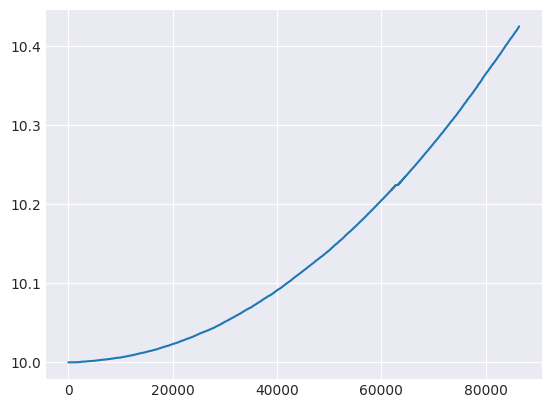

In [26]:
plt.plot(np.linalg.norm(vis_master.load_dataset("true_states")[:,:3]-vis_slave.load_dataset("true_states")[:,:3],axis=1))
plt.show()

In [14]:
run -i run_formation_crtbp.py

🚀 MCPC 仿真: Halo_Formation_CRTBP
   任务ID: 20260404_011518_26302_606ecaf0
   仿真时长: 0.5 天
   积分步长: 10.0 秒
   积分器: rk4
   输出文件: /home/huo/Projects/multistagecophasing/data/Halo_Formation_CRTBP_20260404_011518_26302_606ecaf0.h5
[HDF5Logger] 初始化完成，文件: /home/huo/Projects/multistagecophasing/data/Halo_Formation_CRTBP_20260404_011518_26302_606ecaf0.h5
[HDF5Logger] 缓冲区大小: 500, 压缩: True
[HDF5Logger] 文件结构初始化完成
[-7.96752930e-01  0.00000000e+00  9.99999683e+02  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
[  0. 100.   0.   0.   0.   0.]
[-7.96752930e-01 -1.00000000e+02  9.99999683e+02  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
[ 1.59347534e+00  0.00000000e+00 -1.99999937e+03  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
[   0. -100.    0.    0.    0.    0.]
[ 1.59347534e+00  1.00000000e+02 -1.99999937e+03  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
  [Day 0.0] 进度:  0.0% | 最大相对距离:   2000.000m
[-7.96752930e-01  0.00000000e+00  9.99999683e+02  7.34597831e-07
  1.03674597e-04 -1.036

Targets group exists
  deputy_DEP1: [  0. 100.   0.   0.   0.   0.]
  deputy_DEP2: [   0. -100.    0.    0.    0.    0.]
[[ 1.00007869e+02 -7.87413047e-02  9.59973594e-03]
 [ 1.00007104e+02 -7.10902761e-02  9.61584665e-03]
 [ 1.00006625e+02 -6.63001056e-02  9.62969016e-03]
 [ 1.00006619e+02 -6.62440177e-02  9.63978219e-03]
 [ 1.00006774e+02 -6.77912793e-02  9.64860371e-03]]


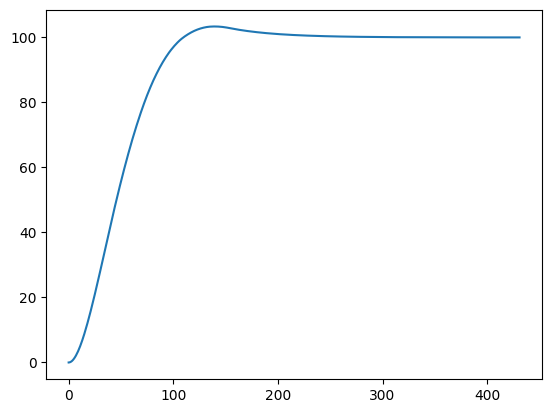

In [13]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
with h5py.File('data/Halo_Formation_CRTBP_20260404_010734_26302_4bbc6347.h5', 'r') as f:
    if 'metadata/targets' in f:
        print('Targets group exists')
        for key in f['metadata/targets']:
            print(f'  {key}: {f[f"metadata/targets/{key}"][()]}')
    else:
        print('No targets group found')
    print(f["formation/deputy_DEP1/rel_position"][()][-5:,:])
    plt.plot(f["formation/deputy_DEP1/rel_position"][()][:,0])
plt.show()